# Objective
# Our core research question:
    Can we accurately predict apartment prices in Buenos Aires based on characteristics like size, type, and location?
    Answering that question is a three-stage process, all of which this lesson covers:
    Clean, structured data — raw data is rarely machine-learning-ready straight from the source.
    Thoughtful feature engineering — transforming raw columns into mathematical inputs a model can actually use.
    A proper train-test split — ensuring our model is evaluated on data it has never seen during training.

# Project workflow
    Used glob to locate multiple CSV files matching a naming pattern and load them into a single DataFrame
    Filtered data to a homogeneous market segment using .loc[] with lambda functions and .query()
    Removed outliers systematically using quantile-based bounds that adapt to any data distribution
    Extracted numeric and categorical features from raw string columns
    Diagnosed missing-value patterns using bar charts and the missingno matrix
    Detected and resolve multicollinearity between numeric features using a correlation heatmap
    Understood why one-hot encoding is needed for categorical variables, why category_encoders is preferred over scikit-learn's OneHotEncoder, and how to apply it
    Split data into training and test sets with scikit-learn's train_test_split

In [1]:
import numpy as np
import pandas as pd
from glob import glob
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# Import and Merge Multiple CSV Files

In [2]:
datasets=glob("buenos-aires-real-estate-*.csv")
datasets

['buenos-aires-real-estate-1.csv',
 'buenos-aires-real-estate-2.csv',
 'buenos-aires-real-estate-3.csv',
 'buenos-aires-real-estate-4.csv',
 'buenos-aires-real-estate-5.csv']

In [3]:
files=[pd.read_csv(x) for x in datasets]

In [4]:
df=pd.concat(files, ignore_index=True)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 43029 entries, 0 to 43028
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   operation                   43029 non-null  str    
 1   property_type               43029 non-null  str    
 2   place_with_parent_names     43029 non-null  str    
 3   lat-lon                     34734 non-null  str    
 4   price                       38073 non-null  float64
 5   currency                    38072 non-null  str    
 6   price_aprox_local_currency  38073 non-null  float64
 7   price_aprox_usd             38073 non-null  float64
 8   surface_total_in_m2         29871 non-null  float64
 9   surface_covered_in_m2       36420 non-null  float64
 10  price_usd_per_m2            24449 non-null  float64
 11  price_per_m2                32642 non-null  float64
 12  floor                       6505 non-null   float64
 13  rooms                       23806 non-null

### We will wrap this into a function called merged_files so that any future notebook can call it with a single line and get back the fully merged DataFrame.

In [5]:
def merged_files(data):
    return pd.concat([pd.read_csv(file) for file in glob(data)], ignore_index=True)
merged_files("buenos-aires-real-estate-*.csv").info()

<class 'pandas.DataFrame'>
RangeIndex: 43029 entries, 0 to 43028
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   operation                   43029 non-null  str    
 1   property_type               43029 non-null  str    
 2   place_with_parent_names     43029 non-null  str    
 3   lat-lon                     34734 non-null  str    
 4   price                       38073 non-null  float64
 5   currency                    38072 non-null  str    
 6   price_aprox_local_currency  38073 non-null  float64
 7   price_aprox_usd             38073 non-null  float64
 8   surface_total_in_m2         29871 non-null  float64
 9   surface_covered_in_m2       36420 non-null  float64
 10  price_usd_per_m2            24449 non-null  float64
 11  price_per_m2                32642 non-null  float64
 12  floor                       6505 non-null   float64
 13  rooms                       23806 non-null

# Data Cleaning

#                       Problems                and                           Effect on model if ignored
    Market heterogeneity — listings span multiple property types and cities -	Model learns inconsistent patterns; predictions are mediocre everywhere
    Extreme outliers — unusual surface area values	-Regression coefficients bend toward extreme cases, reducing accuracy for typical properties
    Missing values — some columns are >50% empty	-Filling with mean/median invents data; better to drop and avoid noise
    Redundant features — highly correlated columns	-Model cannot isolate individual feature effects; coefficients become unstable
    String-encoded numbers — coordinates stored as "-34.60,-58.38"	-Cannot be used in matrix multiplication until split and cast to float
    Data leakage — price-derived columns in the feature set	  -Model "cheats" by using the answer; fails completely on new listings

## dealing with Market heterogeneity

# Filter to Capital Federal Only
    Why Filter to Capital Federal?
    The raw dataset spans Capital Federal (the autonomous city of Buenos Aires) and Greater Buenos Aires (GBA) — two fundamentally different real estate markets that should not be modeled together.    
    Capital Federal: Dense urban core where walkability, transit proximity, building amenities, and neighborhood prestige drive high prices per square meter. The key features are size and location within the city.
    Greater Buenos Aires: Diverse suburban and semi-rural zones where lot size, commute distance, and proximity to commercial centers matter more. A different set of features drives prices.
    Mixing them produces a heterogeneous dataset — a model trained on both would be mediocre at predicting in either market, because the pricing logic differs. One linear equation cannot simultaneously capture urban Palermo dynamics and suburban La Matanza dynamics.
    Additional filters:
    Apartments only — houses and commercial spaces follow different pricing mechanics (lot size, zoning, business revenue potential)
    Price < $400,000 — caps the range to typical residential buyers, excluding luxury outliers whose prices are driven by factors our features do not capture

In [6]:
def filtered_df(data):
    return (df
            .loc[lambda x: x["place_with_parent_names"].str.contains("Capital Federal")]
            .query('property_type == "apartment"')
            .query('price_aprox_usd < 400_000')
           )

# Handling Outliers
    Even within Capital Federal apartments under $400K, the surface area column (surface_covered_in_m2) still contains extreme values that would distort the model's learned coefficients.

In [7]:
def outliers(data):
    return data.loc[lambda x : x["surface_covered_in_m2"].between(x["surface_covered_in_m2"].quantile(0.1),x["surface_covered_in_m2"].quantile(0.9))]

# Extracting Features from String Columns

### Our dataset contains two columns that store multiple pieces of information bundled into a single string. A machine learning model cannot work with strings directly — we need to extract the numeric and categorical information encoded inside them.

In [8]:
def modify_cols(data):
    return (
        data
        .assign(
            lat=lambda x: x["lat-lon"].str.split(",", expand=True)[0].astype(float),      # <--- "lat-lon"
            lon=lambda x: x["lat-lon"].str.split(",", expand=True)[1].astype(float),      # <--- "lat-lon"
            neighborhood=lambda x: x["place_with_parent_names"].str.split("|", expand=True)[3]            # <--- "place_with_parent_names"
        )
    )

check_cols = modify_cols(df)
check_cols.info()

<class 'pandas.DataFrame'>
RangeIndex: 43029 entries, 0 to 43028
Data columns (total 19 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   operation                   43029 non-null  str    
 1   property_type               43029 non-null  str    
 2   place_with_parent_names     43029 non-null  str    
 3   lat-lon                     34734 non-null  str    
 4   price                       38073 non-null  float64
 5   currency                    38072 non-null  str    
 6   price_aprox_local_currency  38073 non-null  float64
 7   price_aprox_usd             38073 non-null  float64
 8   surface_total_in_m2         29871 non-null  float64
 9   surface_covered_in_m2       36420 non-null  float64
 10  price_usd_per_m2            24449 non-null  float64
 11  price_per_m2                32642 non-null  float64
 12  floor                       6505 non-null   float64
 13  rooms                       23806 non-null

# Missing Values Analysis

### After filtering, outlier removal, and feature extraction, we need to understand where our data has gaps. Missing values in machine learning are not just an inconvenience — they require a deliberate decision for each affected column.

### Our approach: Visualize first, decide second. Two complementary plots reveal both the magnitude of missingness (how many values are missing per column?) and the pattern (do rows tend to be missing multiple columns together?).

    🔍 Why does the pattern matter?
    If currency, price_aprox_local_currency, and price_aprox_usd are always missing together, they share the same source — likely listings that did not record price information at all. Imputing one while keeping the others would create a logically inconsistent record. Understanding co-occurrence of missingness guides better decisions.

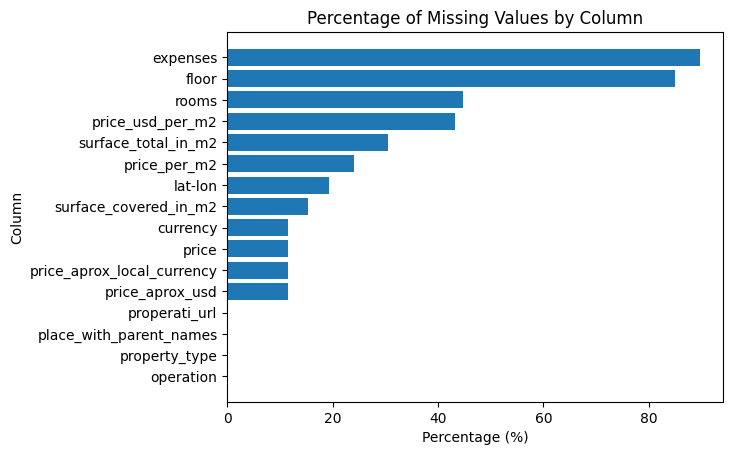

In [9]:
# Percentage of missing values by column
nan_columns_percentage = (df.isna().sum(axis=0) * 100 / len(df)).sort_values()

fig, ax = plt.subplots()

# Horizontal bar plot
ax.barh(y=nan_columns_percentage.index, width=nan_columns_percentage)
ax.set_title('Percentage of Missing Values by Column')
ax.set_xlabel('Percentage (%)')
ax.set_ylabel('Column')
plt.show()

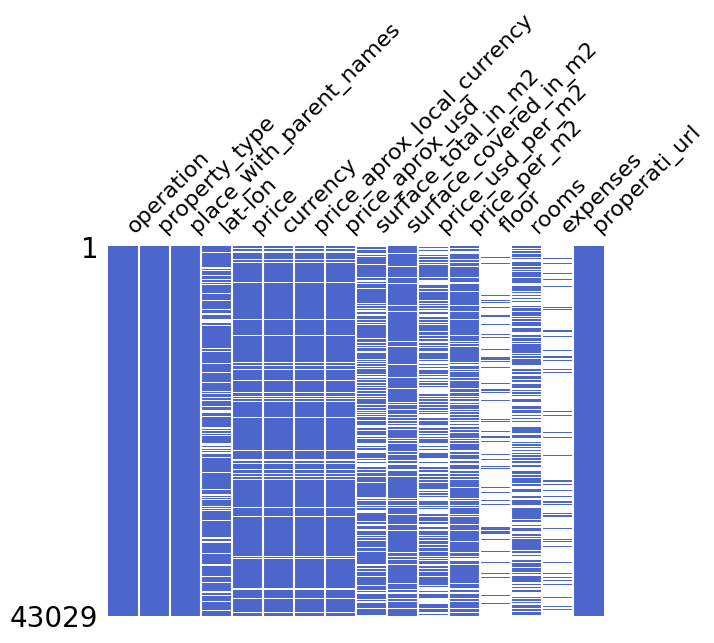

In [10]:
import missingno as msno
# Plot missing values with color royalblue
fig, ax = plt.subplots()
msno.matrix(df, color=(0.3, 0.4, 0.8), ax=ax)
plt.show()

# Multicollinearity Analysis

### The canonical example in our dataset:
    surface_total_in_m2 (total area including balconies, terraces, parking) and surface_covered_in_m2 (indoor living area only) are nearly perfectly correlated — correlation > 0.9. Keeping both gives the model two near-identical signals and produces unstable, uninterpretable coefficients.

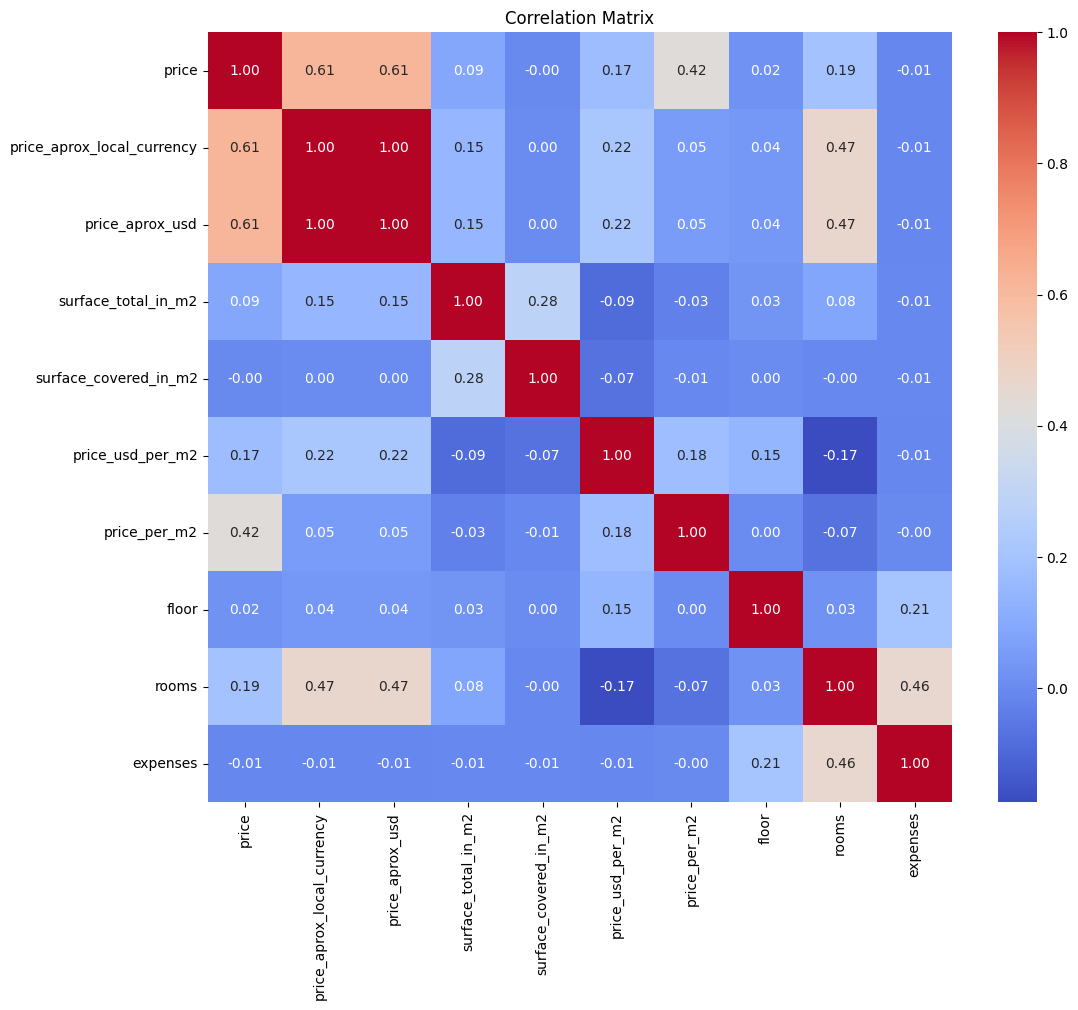

In [11]:
# Calculate correlation matrix for numeric columns
corr_matrix = df.select_dtypes(include='number').corr()  # <--- .corr()

# Plot heatmap
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', ax=ax)
ax.set_title('Correlation Matrix')
plt.show()

# Dropping Unnecessary Columns
    Based on the missing value analysis and the multicollinearity heatmap, we now have a principled list of columns to remove. Each drop has a specific reason — this is not arbitrary data reduction.

In [12]:
drop_cols = [
    "lat-lon", "place_with_parent_names",
    "floor", "expenses", "rooms", "price",
    "price_aprox_local_currency", "price_usd_per_m2",
    "price_per_m2", "operation", "property_type", "currency",
    "properati_url", "surface_total_in_m2"
]

# The Master Cleaning Function¶
    We now have five discrete cleaning functions:
    
    merged_files() — loads all CSVs and stacks them into one DataFrame
    filter_df() — keeps only Capital Federal apartments under $400K
    outliers_df() — removes the bottom and top 10% by surface area
    modify_cols() — extracts lat, lon, and neighborhood from string columns
    A drop step — removes all unnecessary columns

In [13]:
def clean_files(file_paths):
    drop_cols = [
        "lat-lon", "place_with_parent_names",
        "floor", "expenses", "rooms", "price",
        "price_aprox_local_currency", "price_usd_per_m2",
        "price_per_m2", "operation", "property_type", "currency",
        "properati_url", "surface_total_in_m2"
    ]

    return (
        merged_files(file_paths)
        .pipe(filtered_df)
        .pipe(outliers)
        .pipe(modify_cols)
        .drop(columns=drop_cols)
        .dropna()
    )

clean_df = clean_files("buenos-aires-real-estate-*.csv")
clean_df.info()
clean_df

<class 'pandas.DataFrame'>
Index: 6247 entries, 4 to 43021
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   price_aprox_usd        6247 non-null   float64
 1   surface_covered_in_m2  6247 non-null   float64
 2   lat                    6247 non-null   float64
 3   lon                    6247 non-null   float64
 4   neighborhood           6247 non-null   str    
dtypes: float64(4), str(1)
memory usage: 292.8 KB


,price_aprox_usd,surface_covered_in_m2,lat,lon,neighborhood
4,129000.0,70.0,-34.584651,-58.454693,Chacarita
9,87000.0,42.0,-34.638979,-58.500115,Villa Luro
29,118000.0,54.0,-34.615847,-58.459957,Caballito
40,57000.0,42.0,-34.625222,-58.382382,Constitución
41,90000.0,50.0,-34.610610,-58.412511,Once
...,...,...,...,...,...
42990,290000.0,83.0,-34.639528,-58.519666,Liniers
42997,150000.0,45.0,-34.597825,-58.416439,Palermo
43001,65000.0,42.0,-34.652233,-58.490739,Mataderos
43002,91440.0,48.0,-34.648761,-58.500180,Mataderos


# Split Data into Features and Target

## The X/y Convention¶
    This separation mirrors the mathematical notation of supervised learning. Every scikit-learn model expects:
    X — the feature matrix: a 2D array where rows are observations (individual apartments) and columns are features (measurable characteristics used to predict price). We use uppercase X because it represents a 2-dimensional matrix.
    y — the target vector: a 1D array containing the value we want to predict — price_aprox_usd. We use lowercase y because it is a 1-dimensional vector (one number per row).

### 💡 Why does this convention matter? Scikit-learn's API is consistent across all models: model.fit(X_train, y_train) and model.predict(X_test). When you learn this convention once, it applies to every scikit-learn estimator — linear regression, Ridge, Lasso, Random Forest, XGBoost. The X/y split is the universal entry point to the entire scikit-learn ecosystem.

In [14]:
target= "price_aprox_usd"
features= [col for col in clean_df.columns if col not in target]
y = clean_df[target]
X =clean_df[features]
print(f"y shape: {y.shape}")
print(f"X shape: {X.shape}")

y shape: (6247,)
X shape: (6247, 4)


# Our Modeling Goal: The Linear Regression Equation
    Everything we have done — merging, filtering, removing outliers, feature extraction, handling missing values, resolving multicollinearity — has been preparation for one purpose: fitting a linear regression model that predicts apartment prices.

# What the Model Is Learning

During training, scikit-learn finds the values of $\beta_0, \beta_1, \beta_2, \beta_3, \beta_4$ that minimize the total prediction error across all training examples. This optimization is called **Ordinary Least Squares (OLS)** — it minimizes the sum of squared differences between predicted and actual prices:

$$
\min \sum_{i=1}^{n} (\hat{y}_i - y_i)^2
$$

# Why Every Cleaning Decision Had a Consequence

Each data preparation step was not just housekeeping — it had a direct mathematical effect on whether the equation above produces reliable results:

- **Outliers removed:** Squared errors from extreme values dominate the OLS objective. One outlier with a price error of 200,000 contributes $4 \times 10^{10}$ to the sum — equivalent to 40,000 predictions that are 1,000 off. The model bends coefficients toward that outlier at the expense of typical cases.

- **Multicollinearity resolved:** When $x_1$ and $x_2$ are nearly identical, the matrix equation that OLS solves becomes nearly **singular** (not invertible). The coefficients $\beta_1$ and $\beta_2$ blow up to compensate for each other — large positive and large negative values that happen to cancel out for training data but generalize poorly.

- **Data leakage eliminated:** Columns like `price_usd_per_m2` are derived from the target. Keeping them gives the OLS equation a shortcut: it can achieve near-zero training error by learning

$$
\hat{y} \approx x_{\text{price\_per\_m2}} \times \text{surface}
$$

but this "model" cannot be used in production where sale prices are unknown.

- **Missing values handled:** OLS requires a complete matrix — no `NaN` values. Rows with missing values in key features are simply dropped from the calculation.

> 🎯 **The takeaway:** Data cleaning is not a preliminary chore — it is a mathematical prerequisite for the OLS equation to be solvable, stable, and generalizable.

In Lessons 2, 3, and 4, we will fit this equation, measure its accuracy, improve it with regularization, and select the best version.

# Encoding Categorical Variables: One-Hot Encoding
    Our linear regression equation operates on numbers — it uses multiplication and addition. But the neighborhood feature contains text: "Palermo", "Recoleta", "San Telmo". Text cannot participate in the equation until it is converted to numeric form.

### Why Not Assign Integers?
    The obvious fix — replace "Palermo" with 1, "Recoleta" with 2, "San Telmo" with 3 — is deeply problematic. The model would interpret these as a numeric scale:
    "Recoleta is twice as valuable as Palermo" (2 vs. 1)
    "San Telmo is 50% more valuable than Recoleta" (3 vs. 2)
    These implications are arbitrary and false. Neighborhoods have no such ordering. The integer encoding imposes a structure that does not exist in reality.

## The Solution: One-Hot Encoding
    One-hot encoding creates one binary column per unique category. Each new column answers a single yes/no question: "Is this property located in neighborhood X?"
    Before encoding:

### The high-cardinality problem

    Buenos Aires has 50+ neighborhoods. Naively one-hot encoding all of them adds 50+ new columns and creates four compounding problems:
    
    Curse of dimensionality: The model needs proportionally more data to reliably learn patterns with 50+ extra columns. Many neighborhoods may have only dozens of listings — too few to estimate a reliable coefficient.
    Overfitting risk: With enough neighborhood-specific columns, the model can memorize micro-level location quirks rather than learning the general price signal. It performs well on training data but poorly on new listings.
    Sparse data: Each row has exactly one 1 across 50+ neighborhood columns. Most of the data is zeros — computationally wasteful.
    Computational cost: Larger feature matrices mean more memory, slower training, and slower iteration during development.
    💡 Why category_encoders instead of scikit-learn's OneHotEncoder?
    
    Scikit-learn's OneHotEncoder generates column names like x0_0, x0_1, x0_2 — anonymous indices. When you inspect which neighborhoods drive price most strongly, you cannot tell which column represents Palermo and which represents Caballito.
    
    category_encoders.OneHotEncoder generates interpretable names: neighborhood_Palermo, neighborhood_Recoleta, neighborhood_SanTelmo. Every coefficient maps directly to a readable neighborhood name.
    
    This matters enormously for three practical reasons:
    
    Debugging: You can spot whether a neighborhood that should be important has a reasonable coefficient
    Stakeholder communication: You can explain model results in human-readable terms
    Feature selection: Lessons 3 and 4 will drop neighborhood columns with near-zero coefficients — you need to know which ones to drop
    We make this choice here — in the first lesson where one-hot encoding appears — so that all downstream steps inherit readable, debuggable feature names.

In [15]:
# Start with cleaned data, select relevant columns, and show first few rows
sample_df = (
    clean_df
    [['neighborhood', 'price_aprox_usd']]  # <--- Select only these two columns
    .head(5)  # <--- Get first 5 rows to see the original format
)

print("BEFORE One-Hot Encoding:")
print(sample_df)
print(f"\nUnique neighborhoods in sample: {sample_df['neighborhood'].unique()}")

BEFORE One-Hot Encoding:
    neighborhood  price_aprox_usd
4      Chacarita         129000.0
9     Villa Luro          87000.0
29     Caballito         118000.0
40  Constitución          57000.0
41          Once          90000.0

Unique neighborhoods in sample: <StringArray>
['Chacarita', 'Villa Luro', 'Caballito', 'Constitución', 'Once']
Length: 5, dtype: str


In [16]:
# Transform categorical column into multiple binary columns
encoded_df = (
    sample_df
    .assign(
        is_palermo = (clean_df['neighborhood'] == 'Villa Luro').astype(int),  
        is_caballito = (clean_df['neighborhood'] == 'Caballito').astype(int),  
        is_villa_luro = (clean_df['neighborhood'] == 'Villa Luro').astype(int),  
    )
    .drop(columns=['neighborhood'])  # <--- Remove the original text column (we no longer need it)
)

print("\nAFTER One-Hot Encoding:")
print(encoded_df)


AFTER One-Hot Encoding:
    price_aprox_usd  is_palermo  is_caballito  is_villa_luro
4          129000.0           0             0              0
9           87000.0           1             0              1
29         118000.0           0             1              0
40          57000.0           0             0              0
41          90000.0           0             0              0


# Train-Test Split in Scikit-Learn

### Why a Train-Test Split?

    A train-test split divides the dataset into two non-overlapping portions:
    
    Training set (80%): Used to teach the model — scikit-learn sees these examples and adjusts the regression coefficients to minimize prediction error
    Test set (20%): Held out completely — the model never sees these during training; we use them only to measure real-world performance
    Evaluating on training data would be like a professor grading students on the exact practice questions they used to study. Of course they score well — but that score tells you nothing about whether they actually understood the material. The test set is the "real exam": problems the model has never practiced on.

The key insight: A model's training accuracy and its test accuracy are two very different numbers. A large gap between them is the signature of overfitting — the model memorized training examples rather than learning generalizable patterns.

# The 80/20 Rule — Convention, Not Law

The 80/20 ratio reflects a fundamental tension in every machine learning project:

- The model **learns** from training data — more training data means more patterns to discover, more stable coefficient estimates, and better generalization.

- The model is **evaluated** on test data — more test data means a more reliable, lower-variance performance estimate.

The 80/20 split balances these competing needs for most medium-sized datasets. The right split depends on your data volume:

| Dataset size | Typical split | Reasoning |
|---|---|---|
| Small (<1,000 rows) | 90/10 | Cannot afford to lose training data; every row matters |
| Medium (1,000–100,000 rows) | 80/20 | Classic default — our Buenos Aires dataset falls here |
| Large (100,000+ rows) | 95/5 or 99/1 | Even 1% of 100,000 rows gives 1,000 test examples — plenty for reliable evaluation |

---

# `random_state=42` — Reproducibility

`random_state` seeds the random number generator so the split is **identical every time** the cell is executed.

Without it:

- Two students running the same notebook would get different splits.

- Model comparisons between Lessons 2, 3, and 4 would be meaningless — each model might have trained on different properties.

- Debugging would be nearly impossible — results would change between runs for no visible reason.

In [17]:
from sklearn.model_selection import train_test_split

# Split into train and test sets (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42  # <--- X, y, test_size=0.2, random_state=42
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

Training set: 4997 samples
Test set: 1250 samples


In [18]:
assert 'X_train' in globals(), "❌ You must create a variable named 'X_train'."
assert 'X_test' in globals(), "❌ You must create a variable named 'X_test'."
assert 'y_train' in globals(), "❌ You must create a variable named 'y_train'."
assert 'y_test' in globals(), "❌ You must create a variable named 'y_test'."
assert len(X_train) + len(X_test) == len(X), "❌ Train and test sets don't add up to original size."
assert abs(len(X_test) / len(X) - 0.2) < 0.01, "❌ Test set should be approximately 20% of the data."
assert len(X_train) == len(y_train), "❌ X_train and y_train must have the same length."
assert len(X_test) == len(y_test), "❌ X_test and y_test must have the same length."
print("✅ Train-test split completed successfully!")

✅ Train-test split completed successfully!


# Linear Regression:Our First Predictive Model

### We are going to teach a machine to predict apartment prices.

    The concept is straightforward: show the model enough labeled examples — apartments where we already know both the size and the sale price — and it will learn the mathematical relationship between them. Once it has learned that relationship, give it a new apartment's size and it will estimate the price.
    At first we'll focuse on one feature (surface_covered_in_m2) rather than all available features. This is intentional. Starting with a single variable lets us visualize exactly what the model is doing — we can draw the predictions as a line on a scatter plot, see where the model is right and where it is wrong, and build genuine intuition about how linear regression works before adding complexity.

# Import libraries for model building

In [19]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# Preparing the Data and Feature selection

In [20]:
X= clean_df[["surface_covered_in_m2"]]     #returns a DataFrame with one column
y=clean_df["price_aprox_usd"]

# Train-Test Split

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42 
)

print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")

Training set size: 4997
Test set size: 1250


# Establishing a Baseline

### A baseline answers the question: "How well could we do without any modeling at all?" Without a baseline, we have no way to judge whether our model is actually learning anything useful.
## The mean baseline: If someone asked you "how much does a Buenos Aires apartment cost?" and you had to give one number for every apartment regardless of size, your best answer would be the mean price across all training examples. This is the most naïve possible prediction — it ignores all features and simply returns the average for every single query.

In [23]:
y_mean=y_train.mean()
print(y_mean)

134635.8685691415


# Measuring Baseline Performance: MAE
    Now we apply the mean as our prediction for every test apartment and measure how far off we are. The metric we use is Mean Absolute Error (MAE).

# MAE: Intuition

The Mean Absolute Error measures the average *magnitude* of prediction errors. For each test apartment, compute the absolute difference between the actual price and the predicted price (the mean). Average those absolute differences across all test apartments.

$$
MAE = \frac{1}{n}\sum_{i=1}^{n}|y_i-\hat{y}_i|
$$


## Why absolute value instead of just the average difference?

Raw differences `(actual - predicted)` cancel out. A $50,000 overestimate and a $50,000 underestimate would average to zero — falsely suggesting perfect accuracy.

Taking the absolute value prevents this cancellation, so the MAE reflects the true average size of errors regardless of direction.


## Interpreting MAE in practical terms:

A baseline MAE of **$X means**:

> "If we predict the same average price for every apartment, we would be off by $X on average."

This is the standard of accuracy a brain-dead predictor achieves. Our trained model must do better than this to justify its complexity.


## Why use the training mean, not the test mean?

In production, we would not know the test prices when making predictions — that is the whole point.

The training mean is the only honest estimate of the population mean that is available at prediction time.

Using the test mean would again be data leakage — peeking at information we would not have in the real world.

In [26]:
y_pred_baseline= [y_mean] * len(y_test)
mae_baseline= mean_absolute_error(y_test, y_pred_baseline)
print("Baseline MAE:", mae_baseline)

Baseline MAE: 44515.61274011767
